# Beijing PM2.5 Forecasting  
## Notebook 02 — Exploratory Data Analysis (EDA)

In this notebook, we explore the **Aotizhongxin air quality dataset** to understand:

- How PM2.5 behaves over time
- Seasonal and daily patterns
- Relationships between PM2.5, other pollutants, and weather
- The structure of missing values (visually)

No cleaning or modeling is performed here. This notebook is purely about **understanding the data** before making decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (12, 5)

## 1. Load the Baseline Dataset

We load the dataset created in `01_data_loading.ipynb`. This ensures all notebooks use a **consistent starting point**.

In [2]:
DATA_PATH = "../data/processed/aotizhongxin_baseline.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["datetime"], index_col="datetime")

df.head()

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM
datetime,,,,,,,,,,,,
2013-03-01 00:00:00,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4
2013-03-01 01:00:00,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7
2013-03-01 02:00:00,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6
2013-03-01 03:00:00,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1
2013-03-01 04:00:00,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0


## 2. Dataset Overview

We start with a high-level overview:
- Number of observations
- Number of features
- Time span covered

In [3]:
# Shape and time range
print("Shape:", df.shape)
print("Start date:", df.index.min())
print("End date:", df.index.max())

Shape: (35064, 12)
Start date: 2013-03-01 00:00:00
End date: 2017-02-28 23:00:00


## 3. PM2.5 Over Time

This plot shows the **raw hourly PM2.5 concentration** across the full time span.

We are looking for:
- Long-term trends
- Seasonal spikes
- Extreme pollution events

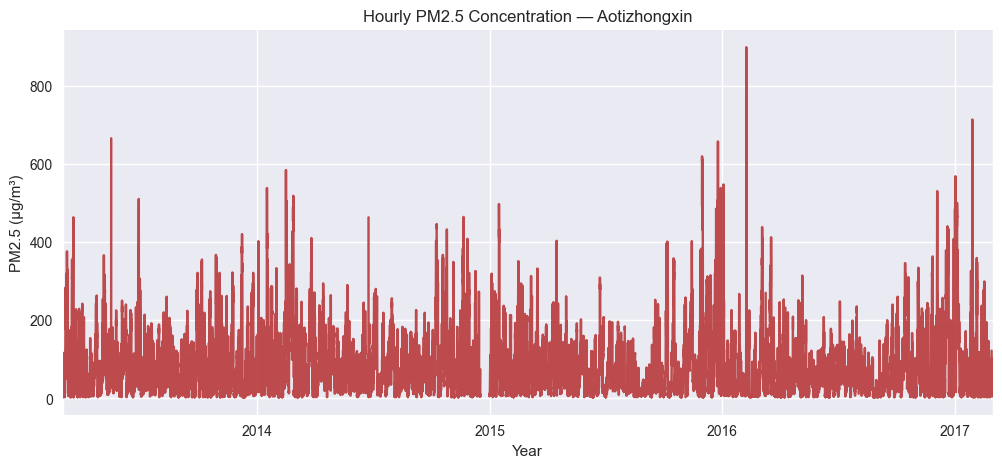

In [4]:
# Tie series plot for PM 2.5
df["PM2.5"].plot(color="firebrick", alpha=0.8)
plt.title("Hourly PM2.5 Concentration — Aotizhongxin")
plt.ylabel("PM2.5 (µg/m³)")
plt.xlabel("Year")
plt.show()

## 4. Seasonal Pattern — Monthly Average PM2.5

Air pollution in Beijing is known to be **seasonal**. We aggregate PM2.5 by month to observe this effect.

C:\Users\ibaan\AppData\Local\Temp\ipykernel_5356\2654253696.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_pm25 = df["PM2.5"].resample("M").mean()


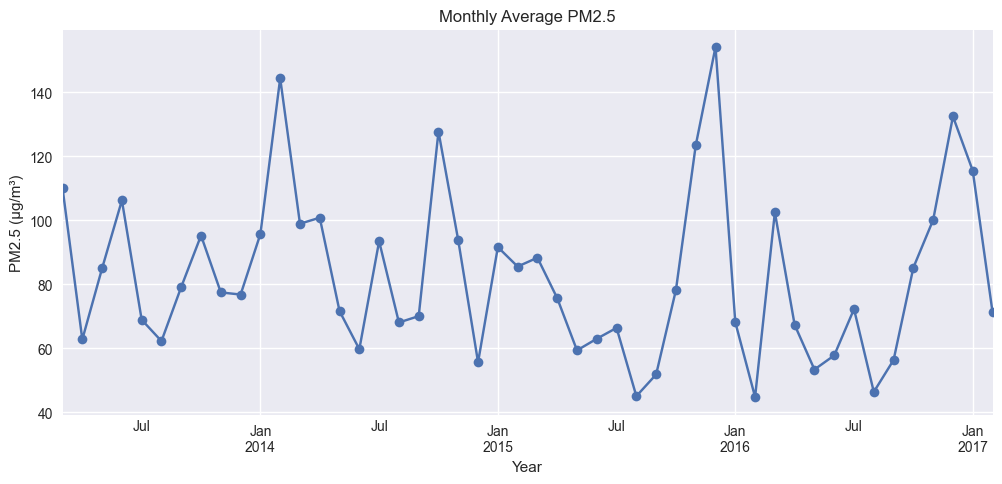

In [5]:
# Monthly averages
monthly_pm25 = df["PM2.5"].resample("M").mean()

monthly_pm25.plot(marker="o")
plt.title("Monthly Average PM2.5")
plt.ylabel("PM2.5 (µg/m³)")
plt.xlabel("Year")
plt.show()

## 5. Daily Pattern — Hourly PM2.5

We examine how PM2.5 varies **within a day**. This often reflects traffic activity and atmospheric conditions.

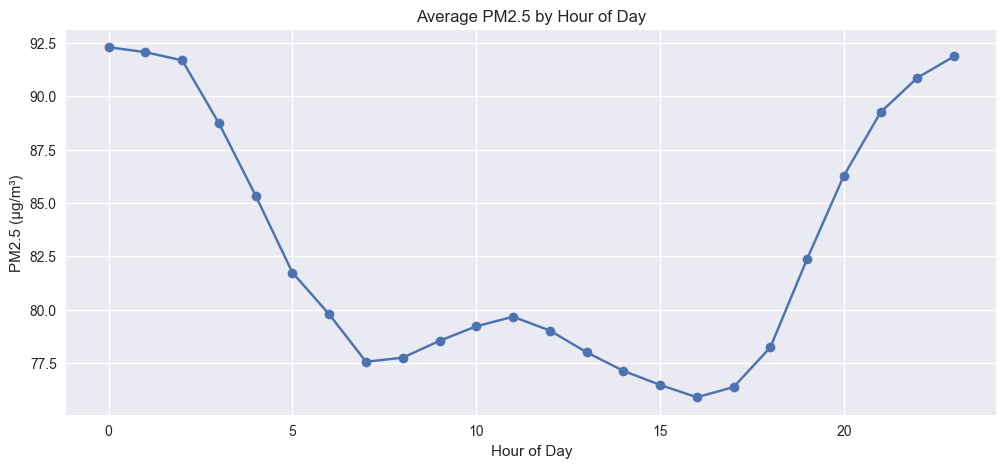

In [6]:
# Hour of day pattern
hourly_pattern = df.groupby(df.index.hour)["PM2.5"].mean()

hourly_pattern.plot(marker="o")
plt.title("Average PM2.5 by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("PM2.5 (µg/m³)")
plt.show()

## 6. Relationship Between PM2.5 and Weather

Weather plays a major role in air pollution dispersion. We visually inspect relationships between PM2.5 and key meteorological variables.

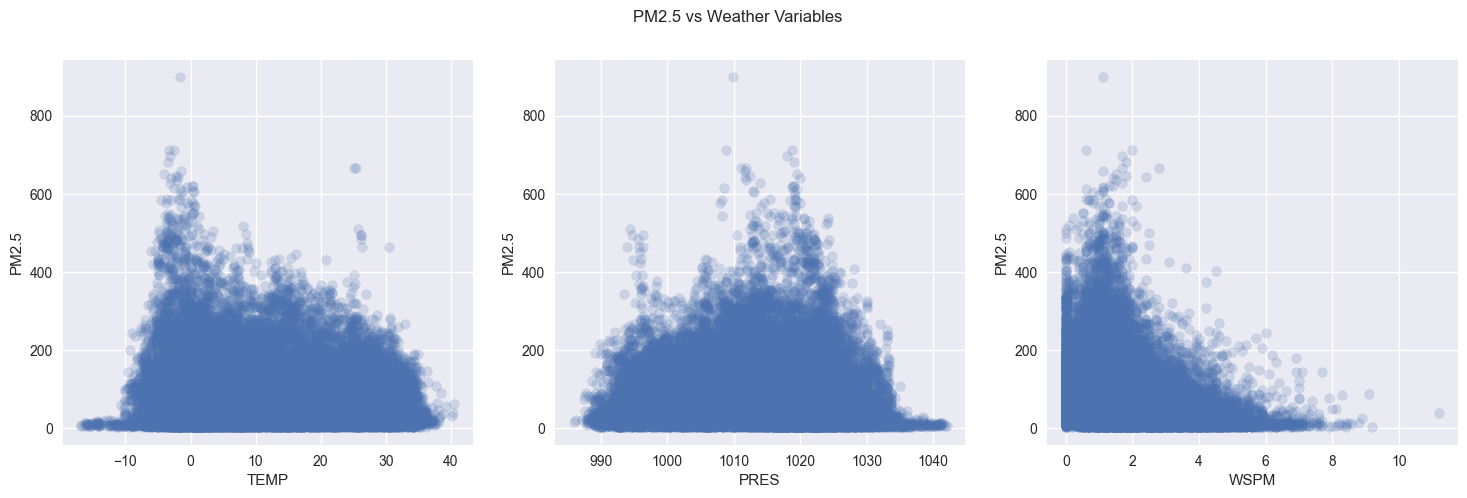

In [7]:
# Scatter plot for weather vs PM2.5
weather_vars = ["TEMP", "PRES", "WSPM"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, var in zip(axes, weather_vars):
    ax.scatter(df[var], df["PM2.5"], alpha=0.2)
    ax.set_xlabel(var)
    ax.set_ylabel("PM2.5")

plt.suptitle("PM2.5 vs Weather Variables")
plt.show()

## 7. PM2.5 vs Other Pollutants

Other pollutants often co-vary with PM2.5. These relationships can provide strong predictive signals.

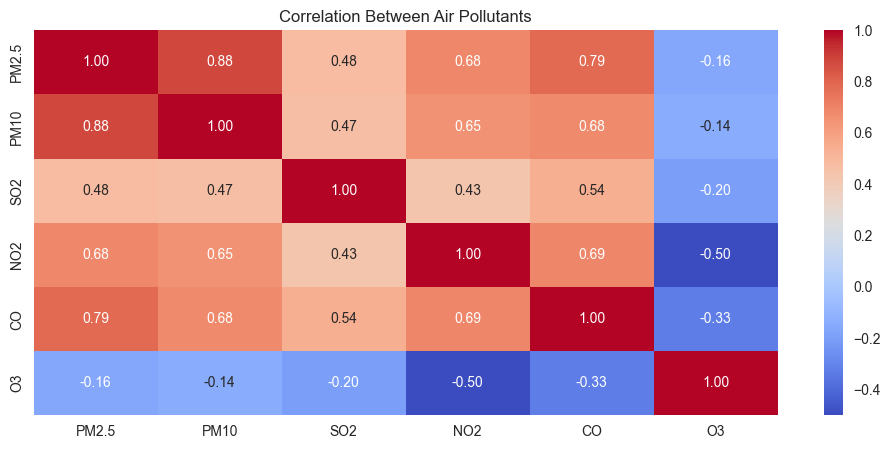

In [8]:
# Correlation heatmap
pollutants = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]

corr = df[pollutants].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Air Pollutants")
plt.show()

## 8. Visual Inspection of Missing Values

We visualize missing data patterns to check whether missing values occur randomly or in contiguous blocks.

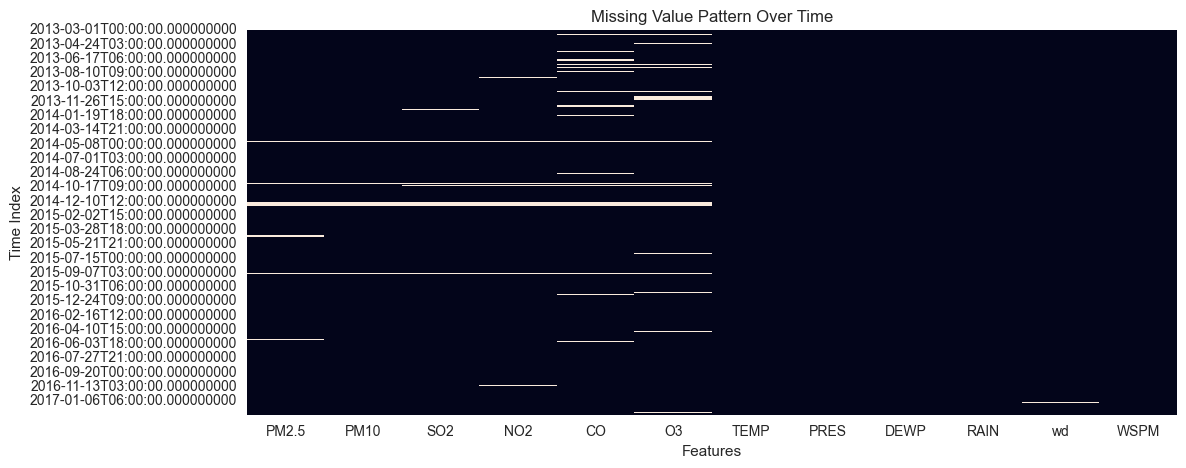

In [9]:
# Missing values heatmap
sns.heatmap(df.isna(), cbar=False)
plt.title("Missing Value Pattern Over Time")
plt.xlabel("Features")
plt.ylabel("Time Index")
plt.show()

## 9. Key Observations from EDA

From the exploratory analysis, several clear patterns emerge:

- **PM2.5 exhibits strong temporal variability**, with frequent sharp spikes and extreme pollution events, especially during winter periods.
- **Seasonality is evident**, with higher monthly average PM2.5 concentrations in colder months and lower levels during warmer seasons.
- A **distinct daily cycle** is observed, where PM2.5 tends to be higher during nighttime and early morning hours, and lower during midday.
- PM2.5 shows **strong positive correlations** with PM10, NO₂, and CO, indicating common emission sources and co-pollutant behavior.
- **O₃ displays a negative correlation** with PM2.5, consistent with known photochemical processes.
- Weather variables influence PM2.5 levels, particularly **wind speed**, where higher wind speeds are associated with lower PM2.5 concentrations.
- Missing values occur in **short, localized intervals** rather than long continuous gaps, suggesting sensor downtime rather than systematic data loss.

Overall, the dataset demonstrates realistic air-quality dynamics and provides a strongfoundation for time-series forecasting using machine learning models.


### EDA Completed

This notebook provided a solid understanding of:
- Temporal behavior of PM2.5
- Seasonal and daily patterns
- Feature relationships
- Missing data structure

We are now ready to **handle missing values properly** and prepare the dataset for modeling.
